In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# import libraries for biological data analysis
import cooler
import bioframe

import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

In [3]:
resolution = 10000
# Load Coolers with the specified resolution dynamically using f-strings
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

In [4]:
# Downloading test data for pileups
# cache = True will doanload the data only if it was not previously downloaded
data_dir = '/usr/users/papantonis1/aman/cooler_down_extra'
#cool_file = cooltools.download_data("HFF_MicroC", cache=True, data_dir=data_dir)
ctcf_peaks_file = cooltools.download_data("HFF_CTCF_binding", cache=True, data_dir=data_dir)
ctcf_fc_file = cooltools.download_data("HFF_CTCF_fc", cache=True, data_dir=data_dir)

In [5]:
# Loading genomic regions

# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler.
# This step is typically not required! we call it only because the test data are reduced.
hg38_arms = hg38_arms.set_index("chrom").loc[clr_1.chromnames].reset_index()

In [6]:
# Loading features for anchors

# Read CTCF peaks data and select only chromosomes present in cooler:
ctcf = bioframe.read_table(ctcf_peaks_file, schema='bed').query(f'chrom in {clr_1.chromnames}')
ctcf['mid'] = (ctcf.end+ctcf.start)//2
ctcf.head()


,chrom,start,end,name,score,strand,mid
0,chr1,778800,778819,MA0139.1_CTCF_human,10.240027,-,778809
1,chr1,869917,869936,MA0139.1_CTCF_human,14.483393,+,869926
2,chr1,904767,904786,MA0139.1_CTCF_human,16.484131,+,904776
3,chr1,912934,912953,MA0139.1_CTCF_human,3.505677,-,912943
4,chr1,921191,921210,MA0139.1_CTCF_human,9.757338,-,921200


In [7]:
# Feature inspection and filtering

In [8]:
# import first
import bbi
from scipy.stats import linregress

In [9]:
# Get CTCF ChIP-Seq fold-change over input for genomic regions centered at the positions of the motifs

flank = 250 # Length of flank to one side from the boundary, in basepairs
ctcf_chip_signal = bbi.stackup(
    ctcf_fc_file,
    ctcf.chrom,
    ctcf.mid-flank,
    ctcf.mid+flank,
    bins=1)

ctcf['FC_score'] = ctcf_chip_signal
ctcf.head()

,chrom,start,end,name,score,strand,mid,FC_score
0,chr1,778800,778819,MA0139.1_CTCF_human,10.240027,-,778809,6.466797
1,chr1,869917,869936,MA0139.1_CTCF_human,14.483393,+,869926,14.423543
2,chr1,904767,904786,MA0139.1_CTCF_human,16.484131,+,904776,24.929019
3,chr1,912934,912953,MA0139.1_CTCF_human,3.505677,-,912943,5.513268
4,chr1,921191,921210,MA0139.1_CTCF_human,9.757338,-,921200,13.955638


In [10]:
# Adding peaks_importance info
ctcf['quartile_score']    = pd.qcut(ctcf['score'], 4, labels=False) + 1
ctcf['quartile_FC_score'] = pd.qcut(ctcf['FC_score'], 4, labels=False) + 1
ctcf['peaks_importance'] = ctcf.apply(
    lambda x: 'Top by both scores' if x.quartile_score==4 and x.quartile_FC_score==4 else
                'Top by Motif score' if x.quartile_score==4 else
                'Top by FC score' if x.quartile_FC_score==4 else 'Ordinary peaks', axis=1
)
ctcf.head()

,chrom,start,end,name,score,strand,mid,FC_score,quartile_score,quartile_FC_score,peaks_importance
0,chr1,778800,778819,MA0139.1_CTCF_human,10.240027,-,778809,6.466797,3,2,Ordinary peaks
1,chr1,869917,869936,MA0139.1_CTCF_human,14.483393,+,869926,14.423543,4,3,Top by Motif score
2,chr1,904767,904786,MA0139.1_CTCF_human,16.484131,+,904776,24.929019,4,4,Top by both scores
3,chr1,912934,912953,MA0139.1_CTCF_human,3.505677,-,912943,5.513268,1,2,Ordinary peaks
4,chr1,921191,921210,MA0139.1_CTCF_human,9.757338,-,921200,13.955638,3,3,Ordinary peaks


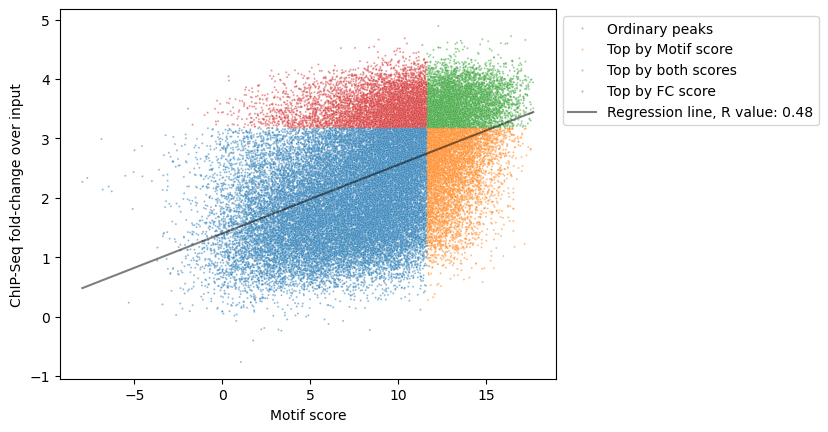

In [11]:

x = ctcf['score']
y = np.log(ctcf['FC_score'])

fig, ax = plt.subplots()

# Remove the label parameter from scatterplot
sns.scatterplot(x=x, y=y, hue=ctcf['peaks_importance'],
    s=2,
    alpha=0.5,
    ax=ax
)

slope, intercept, r, p, se = linregress(x, y)

ax.plot([x.min(), x.max()], [intercept + slope * x.min(), intercept + slope * x.max()],
        alpha=0.5, color='black', label=f"Regression line, R value: {r:.2f}")

ax.set(
    xlabel='Motif score',
    ylabel='ChIP-Seq fold-change over input')

ax.legend(bbox_to_anchor=(1.0,1), loc="upper left")

plt.show()

In [12]:
# Select the CTCF sites that are in top quartile by both the ChIP-Seq data and motif score

sites = ctcf[ctcf['peaks_importance']=='Top by both scores']\
    .sort_values('FC_score', ascending=False)\
    .reset_index(drop=True)
sites.tail()

,chrom,start,end,name,score,strand,mid,FC_score,quartile_score,quartile_FC_score,peaks_importance
5517,chr10,52215931,52215950,MA0139.1_CTCF_human,12.637429,-,52215940,23.929125,4,4,Top by both scores
5518,chr15,75683895,75683914,MA0139.1_CTCF_human,13.872601,-,75683904,23.927095,4,4,Top by both scores
5519,chr19,48351442,48351461,MA0139.1_CTCF_human,16.095693,+,48351451,23.916239,4,4,Top by both scores
5520,chr1,175319811,175319830,MA0139.1_CTCF_human,14.863402,-,175319820,23.908771,4,4,Top by both scores
5521,chr2,169528407,169528426,MA0139.1_CTCF_human,12.117574,+,169528416,23.907999,4,4,Top by both scores


In [41]:
sites = ctcf[ctcf['peaks_importance'].isin(groups)]  # groups = ['Top by both scores', 'Ordinary peaks']

In [42]:
sites

,chrom,start,end,name,score,strand,mid,FC_score,quartile_score,quartile_FC_score,peaks_importance
0,chr1,778800,778819,MA0139.1_CTCF_human,10.240027,-,778809,6.466797,3,2,Ordinary peaks
2,chr1,904767,904786,MA0139.1_CTCF_human,16.484131,+,904776,24.929019,4,4,Top by both scores
3,chr1,912934,912953,MA0139.1_CTCF_human,3.505677,-,912943,5.513268,1,2,Ordinary peaks
4,chr1,921191,921210,MA0139.1_CTCF_human,9.757338,-,921200,13.955638,3,3,Ordinary peaks
5,chr1,938241,938260,MA0139.1_CTCF_human,11.148362,-,938250,17.989089,3,3,Ordinary peaks
...,...,...,...,...,...,...,...,...,...,...,...
46647,chrY,18669962,18669981,MA0139.1_CTCF_human,7.571817,+,18669971,9.811631,2,2,Ordinary peaks
46648,chrY,18952239,18952258,MA0139.1_CTCF_human,6.886887,-,18952248,3.011058,2,1,Ordinary peaks
46649,chrY,18997814,18997833,MA0139.1_CTCF_human,9.279112,-,18997823,4.476893,3,1,Ordinary peaks
46650,chrY,19078048,19078067,MA0139.1_CTCF_human,6.246568,+,19078057,7.263126,2,2,Ordinary peaks


In [43]:
#this step for clustering??

# Some CTCF sites might be located too close in the genome and interfere with analysis.
# We will collapse the sites falling into the same size genomic bins as the resolution of our micro-C data:
sites = bioframe.cluster(sites, min_dist=resolution)\
    .drop_duplicates('cluster')\
    .reset_index(drop=True)
sites.tail()

,chrom,start,end,name,score,strand,mid,FC_score,quartile_score,quartile_FC_score,peaks_importance,cluster,cluster_start,cluster_end
26711,chrY,18669962,18669981,MA0139.1_CTCF_human,7.571817,+,18669971,9.811631,2,2,Ordinary peaks,26711,18669962,18669981
26712,chrY,18952239,18952258,MA0139.1_CTCF_human,6.886887,-,18952248,3.011058,2,1,Ordinary peaks,26712,18952239,18952258
26713,chrY,18997814,18997833,MA0139.1_CTCF_human,9.279112,-,18997823,4.476893,3,1,Ordinary peaks,26713,18997814,18997833
26714,chrY,19078048,19078067,MA0139.1_CTCF_human,6.246568,+,19078057,7.263126,2,2,Ordinary peaks,26714,19078048,19078067
26715,chrY,20558879,20558898,MA0139.1_CTCF_human,9.105302,+,20558888,13.017365,2,3,Ordinary peaks,26715,20558879,20558898


### On-diagonal pileup

In [44]:
stack = cooltools.pileup(clr_1, sites, view_df=hg38_arms, flank=300_000, nproc=4)
# Mirror reflect snippets when the feature is on the opposite strand
mask = np.array(sites.strand == '-', dtype=bool)
stack[mask, :, :] = stack[mask, ::-1, ::-1]

# Aggregate. Note that some pixels might be converted to NaNs after IC, thus we aggregate by nanmean:
mtx = np.nanmean(stack, axis=2)

INFO:root:creating a Pool of 4 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:368: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:371: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:371: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always

In [45]:
print(stack.shape, len(mask))

(26716, 61, 61) 26716


In [46]:
# Load colormap with large number of distinguishable intermediary tones,
# The "fall" colormap in cooltools is exactly for this purpose.
# After this step, you can use "fall" as cmap parameter in matplotlib:
import cooltools.lib.plotting

INFO:root:creating a Pool of 4 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:368: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:371: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:368: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always

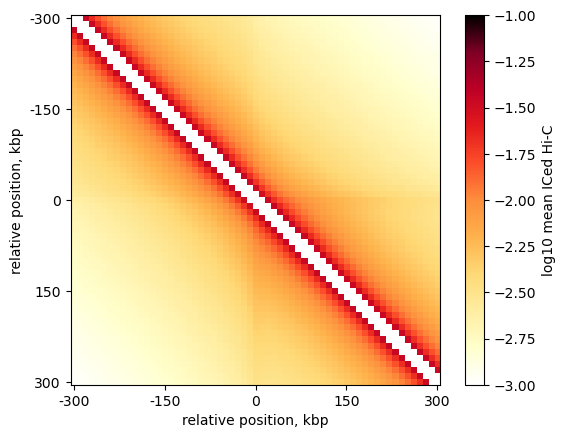

In [48]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import cooltools
import cooltools.lib.plotting

# Perform pileup
stack = cooltools.pileup(clr_1, sites, view_df=hg38_arms, flank=300_000, nproc=4)

# Mirror reflect snippets when the feature is on the opposite strand
mask = np.array(sites.strand == '-', dtype=bool)
stack[mask, :, :] = stack[mask, ::-1, ::-1]

# Aggregate by nanmean
mtx = np.nanmean(stack, axis=0)

# Plot
#mask nan before plotting
plt.imshow(
    ma.masked_invalid(np.log10(mtx)),
    vmin=-3,
    vmax=-1,
    cmap='fall',
    interpolation='none'
)
plt.colorbar(label='log10 mean ICed Hi-C')

resolution = clr_1.binsize  # if clr_1 is a Cooler object, this gives the resolution
flank = 300_000
ticks_pixels = np.linspace(0, flank * 2 // resolution, 5)
ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * resolution // 1000).astype(int)
plt.xticks(ticks_pixels, ticks_kbp)
plt.yticks(ticks_pixels, ticks_kbp)
plt.xlabel('relative position, kbp')
plt.ylabel('relative position, kbp')

plt.show()


In [49]:
expected_1 = cooltools.expected_cis(clr_1, view_df=hg38_arms, nproc=4, chunksize=1_000_000)

INFO:root:creating a Pool of 4 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [50]:
expected_1

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,chr1_p,chr1_p,0,0,NaN,12340,11444,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1_p,chr1_p,1,10000,0.000340,12339,11311,NaN,NaN,NaN,NaN,0.000356,0.000340
2,chr1_p,chr1_p,2,20000,0.029434,12338,11288,711714.0,377.895164,57.684714,0.033478,0.030881,0.029434
3,chr1_p,chr1_p,3,30000,0.019574,12337,11271,446443.0,236.864053,36.187323,0.021015,0.020575,0.019574
4,chr1_p,chr1_p,4,40000,0.014392,12336,11255,327265.0,173.629479,26.529264,0.015427,0.015135,0.014392
...,...,...,...,...,...,...,...,...,...,...,...,...,...
308834,chrY_q,chrY_q,4680,46800000,0.000010,3,0,0.0,0.000000,0.000000,NaN,0.000131,0.000010
308835,chrY_q,chrY_q,4681,46810000,0.000010,2,0,0.0,0.000000,0.000000,NaN,0.000131,0.000010
308836,chrY_q,chrY_q,4682,46820000,0.000010,1,0,0.0,0.000000,0.000000,NaN,0.000131,0.000010
308837,chrM_p,chrM_p,0,0,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# Create the stack of snips:
stack = cooltools.pileup(clr_1, sites, view_df=hg38_arms, expected_df=expected_1, flank=300_000)

# Mirror reflect snippets when the feature is on the opposite strand
mask = np.array(sites.strand == '-', dtype=bool)
stack[mask, :, :] = stack[mask, ::-1, ::-1]

mtx_1 = np.nanmean(stack, axis=0)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:938: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  features_df["region_offset"] = features_df["region"].replace(region_offsets_dict)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:574: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/snipping.py:577: FutureWarning: Series.__getitem__ treating keys as p

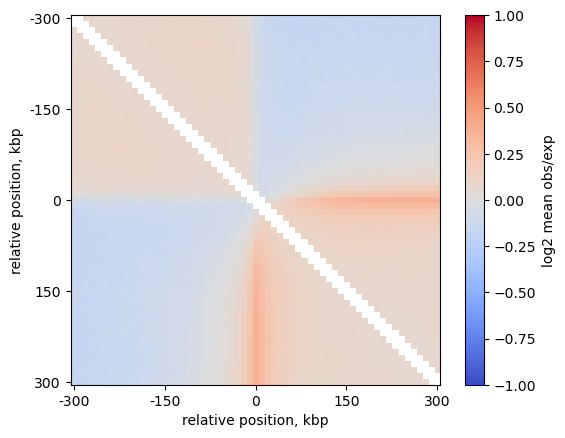

In [52]:
plt.imshow(
    np.log2(mtx_1),
    vmax = 1.0,
    vmin = -1.0,
    cmap='coolwarm',
    interpolation='none')

plt.colorbar(label = 'log2 mean obs/exp')
ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
plt.xticks(ticks_pixels, ticks_kbp)
plt.yticks(ticks_pixels, ticks_kbp)
plt.xlabel('relative position, kbp')
plt.ylabel('relative position, kbp')

plt.show()

/tmp/ipykernel_523776/4059957918.py:12: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack[mask, :, :], axis=0)  # Apply mask to first axis (snippets)
/tmp/ipykernel_523776/4059957918.py:12: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack[mask, :, :], axis=0)  # Apply mask to first axis (snippets)


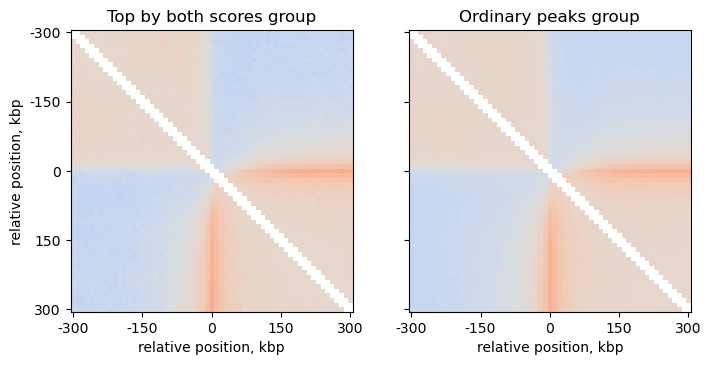

In [59]:
groups = ['Top by both scores', 'Ordinary peaks']
n_groups = len(groups)

ticks_pixels = np.linspace(0, flank*2 // resolution, 5)
ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * resolution // 1000).astype(int)

fig, axs = plt.subplots(1, n_groups, sharex=True, sharey=True, figsize=(4 * n_groups, 4))

for i in range(n_groups):
    # Apply mask to the subset of sites used for stack
    mask = sites.iloc[:len(stack)]['peaks_importance'] == groups[i]
    mtx = np.nanmean(stack[mask, :, :], axis=0)  # Apply mask to first axis (snippets)

    ax = axs[i]
    ax.imshow(
        np.log2(mtx),
        vmax=1.0,
        vmin=-1.0,
        cmap='coolwarm',
        interpolation='none'
    )

    ax.set(
        title=f'{groups[i]} group',
        xticks=ticks_pixels,
        xticklabels=ticks_kbp,
        xlabel='relative position, kbp'
    )

axs[0].set(
    yticks=ticks_pixels,
    yticklabels=ticks_kbp,
    ylabel='relative position, kbp'
)

plt.show()


In [61]:
for group in groups:
    print(f"Number of entries for {group}: {sites[sites['peaks_importance'] == group].shape[0]}")


Number of entries for Top by both scores: 5522
Number of entries for Ordinary peaks: 28849


### Off-diagonal pileup